# RobustBench integration — smoke test

Verifies that `load_cifar10_robust()` in `models.py` works end-to-end:

| Step | What it checks |
|---|---|
| **1** | `robustbench` imports and model downloads correctly |
| **2** | Clean accuracy on 1 000 test images matches expected ~92.4% |
| **3** | `make_oracle()` / `identity_normalize` pipeline is consistent |
| **4** | A single EvolBA attack completes successfully on the robust model |
| **5** | Visual sanity-check of original → adversarial → perturbation |

> **Kernel:** use the `.venv` Python kernel (the one with `robustbench` installed).

## 1. Setup

In [1]:
import os, sys
sys.path.insert(0, os.path.dirname(os.path.abspath('__file__')))

import numpy as np
import torch
import matplotlib.pyplot as plt

import config
from models import load_cifar10_robust, collect_correct, evaluate_accuracy
from evolba import make_oracle, evolba

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
torch.manual_seed(config.SEED)
np.random.seed(config.SEED)

print(f'Device : {DEVICE}')

c:\Users\tomma\Desktop\EVOLUTIONARY COMPUTING\Adversial ML\.venv\Lib\site-packages\robustbench\loaders.py:4: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


Device : cpu


## 2. Load robust model

Downloads `Wang2023Better_WRN-28-10` (WideResNet-28-10) on first run; cached in `~/.cache/robustbench` afterwards.

In [2]:
model, normalize_fn, test_loader = load_cifar10_robust(DEVICE)

print(f'Model        : {config.CIFAR10_ROBUST_MODEL}')
print(f'Threat model : {config.CIFAR10_ROBUST_THREAT}')
print(f'normalize_fn : {normalize_fn.__name__}')   # should be identity_normalize

c:\Users\tomma\Desktop\EVOLUTIONARY COMPUTING\Adversial ML\.venv\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Loading Wang2023Better_WRN-28-10 from RobustBench …


Downloading...
From (original): https://drive.google.com/uc?id=1-6MYKJdECDVGaWjj6GgqvaT95BGKhUvI
From (redirected): https://drive.google.com/uc?id=1-6MYKJdECDVGaWjj6GgqvaT95BGKhUvI&confirm=t&uuid=1c368fc4-3bd8-4e56-9d5c-99b9152b71d8
To: c:\Users\tomma\Desktop\EVOLUTIONARY COMPUTING\Adversial ML\models\cifar10\Linf\Wang2023Better_WRN-28-10.pt
100%|██████████| 146M/146M [00:10<00:00, 14.6MB/s] 

Loaded  (36,479,194 parameters)
Model        : Wang2023Better_WRN-28-10
Threat model : Linf
normalize_fn : identity_normalize


## 3. Clean accuracy (first 1 000 test images)

In [3]:
# Subsample to 1 000 images for speed
subset = torch.utils.data.Subset(test_loader.dataset, range(1000))
subset_loader = torch.utils.data.DataLoader(subset, batch_size=128, shuffle=False, num_workers=0)

acc = evaluate_accuracy(model, normalize_fn, subset_loader, DEVICE)
print(f'Clean accuracy (first 1 000 images): {acc * 100:.2f}%')
print(f'Expected                           : ~92.4%')

assert acc > 0.90, f'Accuracy {acc:.3f} is too low — model may not have loaded correctly'

Clean accuracy (first 1 000 images): 93.20%
Expected                           : ~92.4%


## 4. Oracle consistency check

Verify that `make_oracle()` with `identity_normalize` gives the same predictions as the direct forward pass.

In [4]:
oracle_fn = make_oracle(model, normalize_fn, DEVICE)

# Grab 10 images, compare oracle label vs direct model output
imgs, labels = next(iter(subset_loader))
imgs = imgs[:10]
labels = labels[:10]

mismatches = 0
for i in range(10):
    image_chw = imgs[i].numpy()                          # (3, 32, 32) in [0,1]
    oracle_pred = oracle_fn(image_chw)
    with torch.no_grad():
        direct_pred = model(imgs[i].unsqueeze(0).to(DEVICE)).argmax(1).item()
    if oracle_pred != direct_pred:
        mismatches += 1

print(f'Oracle vs direct-forward mismatches: {mismatches}/10')
assert mismatches == 0, 'Oracle and direct forward pass disagree — check normalize_fn'

Oracle vs direct-forward mismatches: 0/10


## 5. Collect correctly-classified samples

In [5]:
samples = collect_correct(model, normalize_fn, test_loader.dataset, DEVICE, n=20)
print(f'Collected {len(samples)} correctly-classified samples')
print(f'Image shape : {samples[0][0].shape}  dtype : {samples[0][0].dtype}')

Collected 20 correctly-classified samples
Image shape : (3, 32, 32)  dtype : float32


## 6. Single EvolBA attack

Run EvolBA on one image with the full query budget.  
Expect a higher L2 than the standard ResNet-56 result (~3.2) because this model is adversarially trained.

In [8]:
image_chw, true_label = samples[12]
print(f'True class : {config.CIFAR10_CLASSES[true_label]}')

result = evolba(
    oracle_fn,
    image_chw,
    true_label,
    max_queries=config.MAX_Q_CIFAR10,
    bs_steps=config.BS_STEPS,
)

assert result['success'], 'EvolBA failed to find an adversarial example'

adv_label = oracle_fn(result['best_adv'])
print(f"Success            : {result['success']}")
print(f"Queries used       : {result['queries']}")
print(f"L2 after Phase 2   : {result['init_l2']:.4f}")
print(f"L2 after Phase 3   : {result['best_l2']:.4f}")
print(f"L2 reduction       : {result['l2_reduction']:.1f}%")
print(f"Adversarial class  : {config.CIFAR10_CLASSES[adv_label]}")

True class : dog
Success            : True
Queries used       : 3017
L2 after Phase 2   : 3.4163
L2 after Phase 3   : 3.0825
L2 reduction       : 9.8%
Adversarial class  : frog


## 7. Visual check

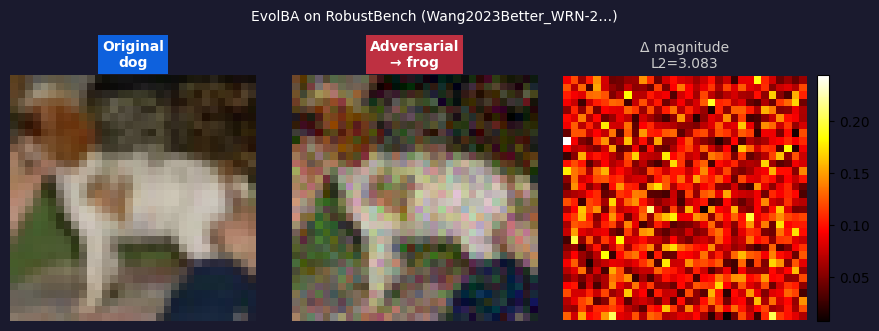

All checks passed.


In [9]:
orig  = image_chw                          # (3, 32, 32)
adv   = result['best_adv']
delta = adv - orig
mag   = np.linalg.norm(delta, axis=0)     # per-pixel L2 across channels (32, 32)

orig_hwc = orig.transpose(1, 2, 0)
adv_hwc  = adv.transpose(1, 2, 0)

fig, axes = plt.subplots(1, 3, figsize=(9, 3.2))
fig.patch.set_facecolor('#1a1a2e')

axes[0].imshow(np.clip(orig_hwc, 0, 1), interpolation='nearest')
axes[0].set_title(f'Original\n{config.CIFAR10_CLASSES[true_label]}',
                  color='white', fontsize=10, fontweight='bold',
                  bbox=dict(facecolor='#0d6efd', alpha=0.85, pad=3, edgecolor='none'))
axes[0].axis('off')

axes[1].imshow(np.clip(adv_hwc, 0, 1), interpolation='nearest')
axes[1].set_title(f'Adversarial\n\u2192 {config.CIFAR10_CLASSES[adv_label]}',
                  color='white', fontsize=10, fontweight='bold',
                  bbox=dict(facecolor='#dc3545', alpha=0.85, pad=3, edgecolor='none'))
axes[1].axis('off')

im = axes[2].imshow(mag, cmap='hot', interpolation='nearest')
axes[2].set_title(f'\u0394 magnitude\nL2={result["best_l2"]:.3f}',
                  color='#cccccc', fontsize=10)
axes[2].axis('off')
fig.colorbar(im, ax=axes[2], fraction=0.046, pad=0.04)

fig.suptitle(
    f'EvolBA on RobustBench ({config.CIFAR10_ROBUST_MODEL[:20]}…)',
    color='white', fontsize=10, y=1.02
)
plt.tight_layout()
plt.savefig('test_robustbench_result.png', dpi=150, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()
print('All checks passed.')